In [4]:
import pyreadstat
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import  average_precision_score
from sklearn.metrics import PrecisionRecallDisplay

In [ ]:
# df_ch = pyreadstat.read_sav('/kaggle/input/malnutrition/ch.sav')[0] #Kaggle dataset
df_ch = pyreadstat.read_sav('/workspaces/malnutrition/Dataset/ch.sav')[0] #GitHub Codespace dataset
# df_ch = pyreadstat.read_sav(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.sav")[0] #Local dataset


# Renaming the columns
features_rename = df_ch[['AN4', 'AN8', 'BD2', 'CA1', 'CA14', 'HH6', 'HL4', 'melevel1', 'cinsurance', 'HH7c', 'windex5', 'WAZ2', 'HAZ2', 'WHZ2']]
df1 = features_rename.rename(columns={
    'AN4': 'child_age',
    'AN8': 'child_weight',
    'BD2': 'ever_breastfed',
    'CA1': 'diarrhoea_last_2_weeks',
    'CA14': 'fever_last_2_weeks',
    'HH6': 'area',
    'HL4': 'child_sex',
    'melevel1': 'mother_education',
    'cinsurance': 'health_insurance',
    'HH7c': 'province',
    'windex5': 'wealth_index',
    'WAZ2': 'underweight',
    'HAZ2': 'stunting',
    'WHZ2': 'wasting'
})

# Remove rows with coded entries in each column
coded_child_age = [99.6, 99.5, 99.4, 99.3]
coded_underweight = [99.99, 99.98, 99.97]
coded_stunting = [99.99, 99.98, 99.97]
coded_wasting = [99.97]
coded_diarrhoea = [9, 8]
coded_fever = [8]
coded_insurance = [9]
coded_breastfed = [9]

df2 = df1.copy()
df2.dropna(inplace=True)

df2 = df2[~df2['child_age'].isin(coded_child_age)]
df2 = df2[~df2['underweight'].isin(coded_underweight)]
df2 = df2[~df2['stunting'].isin(coded_stunting)]
df2 = df2[~df2['wasting'].isin(coded_wasting)] 
df2 = df2[~df2['diarrhoea_last_2_weeks'].isin(coded_diarrhoea)]
df2 = df2[~df2['fever_last_2_weeks'].isin(coded_fever)]
df2 = df2[~df2['health_insurance'].isin(coded_insurance)]
df2 = df2[~df2['ever_breastfed'].isin(coded_breastfed)]

# Convert to Binary Response Variables
df2['underweight'] = [2 if -2 <= x < 2 else 1 for x in df2['underweight']]
df2['stunting'] = [2 if -2 <= x < 2 else 1 for x in df2['stunting']]
df2['wasting'] = [2 if -2 <= x < 2 else 1 for x in df2['wasting']]
df2['malnurished'] = df2[['underweight', 'stunting', 'wasting']].apply(lambda x: 1 if any(i == 1 for i in x) else 0, axis=1)
df2 = df2.drop(['underweight', 'stunting', 'wasting'], axis=1)

# Change binary features from 1/2 to 1/0
df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']] = df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']].replace({1: 1, 2: 0})

# Standardize continuous column
scaler = StandardScaler()
df2['child_weight'] = scaler.fit_transform(df2[['child_weight']])

# One-hot encode nominal categorical column
df3 = pd.get_dummies(df2, columns=['province'], drop_first=True)

# Convert only boolean dummy columns to 0/1
cols_to_convert = df3.columns.difference(['child_weight'])
df3[cols_to_convert] = df3[cols_to_convert].astype(int)

df3.head(2)

,child_age,child_weight,ever_breastfed,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0
0,1,-0.617934,1,0,0,0,1,5,0,1,1,0,0,0,0,0,0
2,2,0.797956,1,1,0,0,0,2,0,1,0,0,0,0,0,0,0


In [3]:
X = df2.drop(columns=['malnurished'])
y = df2['malnurished']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

# Naive Bayes Classifier

In [5]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

In [6]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.64      0.45      0.53       397
           1       0.50      0.69      0.58       320

    accuracy                           0.56       717
   macro avg       0.57      0.57      0.55       717
weighted avg       0.58      0.56      0.55       717



In [8]:
y_probas = nb.predict_proba(X_test)[:, 1]

print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

Average Precision: 0.5781952938372241


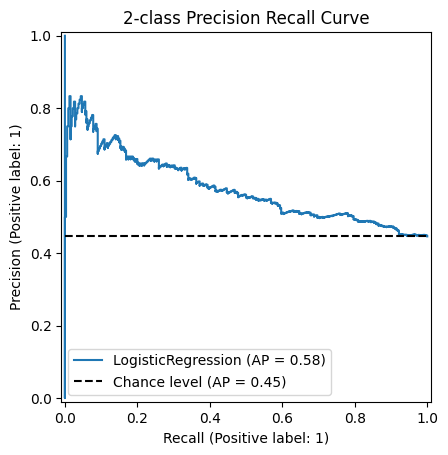

In [10]:
display = PrecisionRecallDisplay.from_estimator(
    nb,
    X_test,
    y_test, 
    name="LogisticRegression",
    plot_chance_level = True,
)
display.ax_.set_title('2-class Precision Recall Curve')
plt.show()

# Hyperparameter Tuning

In [11]:
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

grid_search_nb = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search_nb.fit(X_train, y_train)



Fitting 5 folds for each of 5 candidates, totalling 25 fits


,estimator,GaussianNB()
,param_grid,"{'var_smoothing': [1e-09, 1e-08, ...]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,priors,None


In [12]:
print("Best Parameters:", grid_search_nb.best_params_)
print("Best Cross-Validated Recall:", grid_search_nb.best_score_)

best_nb = grid_search_nb.best_estimator_
y_pred = best_nb.predict(X_test)

print("Recall on Test Set:", recall_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Best Parameters: {'var_smoothing': 1e-09}
Best Cross-Validated Recall: 0.7202328431372549
Recall on Test Set: 0.6875
Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.45      0.53       397
           1       0.50      0.69      0.58       320

    accuracy                           0.56       717
   macro avg       0.57      0.57      0.55       717
weighted avg       0.58      0.56      0.55       717



In [13]:
y_probas = best_nb.predict_proba(X_test)[:, 1]

print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

Average Precision: 0.5781952938372241


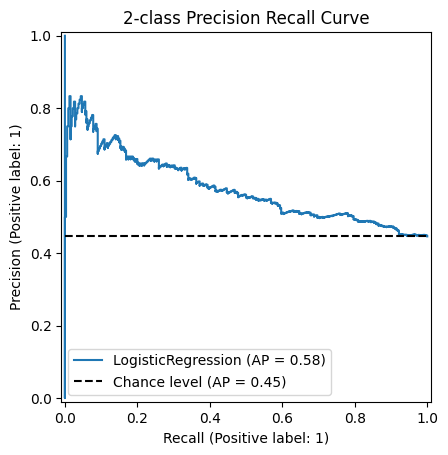

In [14]:
display = PrecisionRecallDisplay.from_estimator(
    best_nb,
    X_test,
    y_test, 
    name="LogisticRegression",
    plot_chance_level = True,
)
display.ax_.set_title('2-class Precision Recall Curve')
plt.show()